## Jupyternotebook for the FPVS application 

In [1]:
%reset -f

import FPyVS_appylication as FP
import FPVS_pycage as FPVS
import cust_funcs as cf
from pathlib import Path
import numpy as np
import importlib
importlib.reload(FP)
importlib.reload(FPVS)
importlib.reload(cf)


<module 'cust_funcs' from 'C:\\Users\\Admin\\anaconda_projects\\FPVS\\FPVS Pypeline\\cust_funcs.py'>

In [ ]:
filepath = Path(r"D:\Goffaux lab\Data set\Python files\BEFR2711.npy")
importlib.reload(FP)
npy_data, meta_data, filpath = FP.convertMATtoPY(filepath)
npy_data, meta_data, filepath = FP.renamechannels(filepath, stepno= 11)
npy_data, meta_data, filepath = FP.electrodelocationchange(filepath, stepno=21)
npy_data, meta_data, filepath = FP.downsampling(filepath, stepno = 31)
npy_data, meta_data, filepath = FP.delete_channels(filepath, stepno = 41)
npy_data, meta_data, filepath = FP.bandpassfilter(filepath,stepno = 51)
npy_data, meta_data, filepath = FP.notchfilter(filepath, stepno = 61)
npy_data, meta_data, filepath = FP.segmentation(filepath, stepno= 71)
npy_data, meta_data, filepath = FP.globalreferencing(filepath, stepno= 81)
filepath = FP.separateepochs(filepath)
# FP.showmesummaryplot(npy_data= npy_data, meta_data= meta_data)

In [42]:
# event_label = 200
# folderpath = 
importlib.reload(FP)
filepath = Path(r"D:\Goffaux lab\Data set\Python files\61_notchfilt 51_but 41_chan-select 31_ds 21_chanlocs 11_chanlabels CHMA0501")
ica, raw, ica_data, eog_indices = FP.performICA(filepath)
FP.overlayICAondata(filepath, ica_data)

Creating RawArray with float64 data, n_channels=70, n_times=921856
    Range : 0 ... 921855 =      0.000 ...  3600.996 secs
Ready.
length of dict: 70


C:\Users\Admin\anaconda_projects\FPVS\FPVS Pypeline\FPyVS_appylication.py:427: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Fitting ICA to data using 70 channels (please be patient, this may take a while)
Selecting by explained variance: 34 components
Fitting ICA took 51.6s.
Using EOG channel: Fp1
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth:

In [43]:
importlib.reload(FP)
rmidx = [2,0]
npy_data, meta_data, filepath = FP.applyICA(filepath, ica, raw, rmidx)
FP.showmesummaryplot(npy_data,meta_data)


Removing ICA components: [2, 0]
Applying ICA to Raw instance
    Transforming to ICA space (34 components)
    Zeroing out 2 ICA components
    Projecting back using 70 PCA components
ICA performed, data saved as  D:\Goffaux lab\Data set\Python files\ica_filt 61_notchfilt 51_but 41_chan-select 31_ds 21_chanlocs 11_chanlabels CHMA0501




In [32]:
importlib.reload(FP)
# filepath = Path(r"D:\Goffaux lab\Data set\Python files\41_chan-select 31_ds 21_chanlocs 11_chanlabels DAFE1803.npy")
# filepath = Path(r"D:\Goffaux lab\Data set\Python files\71_ep 61_notchfilt 51_but 41_chan-select 31_ds 21_chanlocs 11_chanlabels DAAN0411.npy")

# npy_data, meta_data, filepath = FP.segmentation(filepath, stepno= 71)
# print(filepath)
# npy_data, meta_data, filepath = FP.baselinefiltering(filepath, stepno= 81)
# npy_data, meta_data, filepath = FP.globalreferencing(filepath, stepno = 81)
# npy_data, meta_data, _ , _ = FP.loadalldata(filepath)
# print(meta_data['
npy_data_new = np.transpose(raw.get_data())
FP.showmesummaryplot_alt(npy_data_new, meta_data)

In [ ]:
importlib.reload(FP)
folderpath = Path(r"D:\Goffaux lab\Data set\Python files")
eventlabel = 135

# npy_data1, meta_data1, _ = FP.mergeepochs(folderpath,eventlabel)
npy_data, meta_data, filepath = FP.mergeevents(folderpath, eventlabel)
print(npy_data.shape)

In [54]:
importlib.reload(FP)
filepath = Path(r"D:\Goffaux lab\Data set\Python files\200 MERGED")
npy_data, meta_data, filepath = FP.frequencytransform(filepath,stepno = 91)
npy_data, meta_data, filepath = FP.averagingacrosstrials(filepath,stepno = 101)
npy_data, meta_data, filepath = FP.chunking(filepath,stepno = 111)
_, _, _, _, filepath_br, filepath_odd = FP.selectingchunks(filepath,stepno = 121)

br_data, br_meta_data, filepath_br = FP.sumofharmonics(filepath_br,stepno = 131)
br_data_blf, br_meta_data_blf, filepath_br_blf = FP.baselinefiltering(filepath_br,stepno = 141)
print(br_data.shape)

odd_data, odd_meta_data, filepath_odd = FP.sumofharmonics(filepath_odd,stepno = 131)
odd_data_blf, odd_meta_data_blf, filepath_odd_blf = FP.baselinefiltering(filepath_odd,stepno = 141)

FP.showmesummaryplot(br_data,meta_data)

print(odd_data.shape)


Data is transformed to the frequency domain and saved as D:\Goffaux lab\Data set\Python files\91_fft 200 MERGED


Data is averaged across trials and saved as D:\Goffaux lab\Data set\Python files\101_avg 91_fft 200 MERGED


Data is chunked at frequencies of interest and saved as D:\Goffaux lab\Data set\Python files\111_chunk101_avg 91_fft 200 MERGED


Interesting chunks of the data are selected and saved as D:\Goffaux lab\Data set\Python files\111_chunk101_avg 91_fft 200 MERGED


Harmonics of npy_data is summed and the new shape is: (29, 70)


(29, 70)
Harmonics of npy_data is summed and the new shape is: (29, 70)




(29, 70)


In [58]:
filepath = Path(r"D:\Goffaux lab\Data set\Python files\101_avg 91_fft 200 MERGED")
npy_data, meta_data, npyfilepath,metafilepath = FP.loadalldata(filepath)
FP.showmesummaryplot(npy_data, meta_data)

skull_factor:  357.51332307996677
skull_center:  [   0.18318088 -112.00988132  -49.60941955]


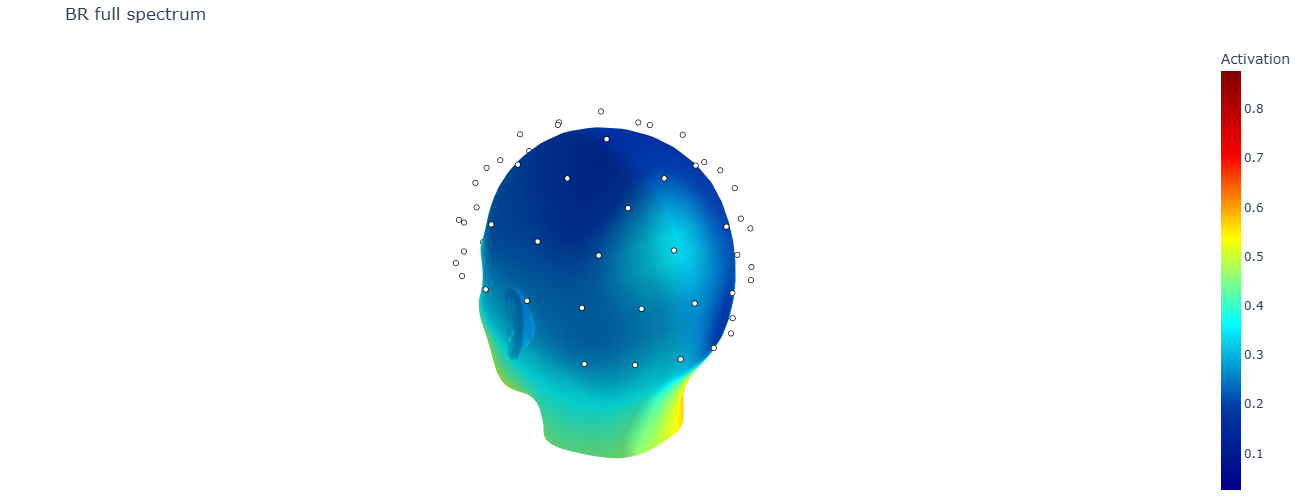

In [56]:
importlib.reload(cf)
midpoint = 1+((br_data.shape[0])//2)
# FP.showmesummaryplot(odd_data,odd_meta_data)
cf.showme3DTopomapnewmesh(br_data[midpoint,:,],br_meta_data,"BR full spectrum")

In [50]:
midpoint = 1+((br_data.shape[0])//2)
# FP.showmesummaryplot(br_data,br_meta_data)
cf.showme3DTopomapnewmesh(br_data[midpoint,:,],br_meta_data)
print(odd_data.shape)
# print(npy_data.shape)

(28, 70, 1, 5)


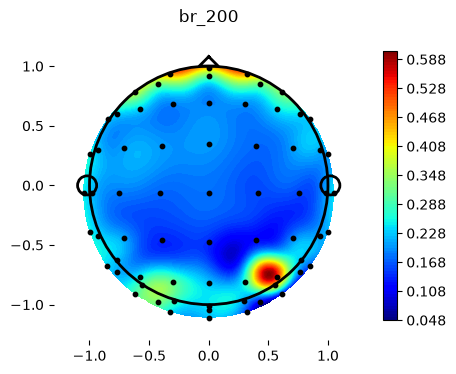

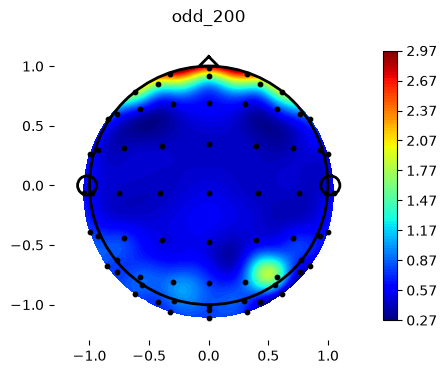

In [19]:
# npy_data, meta_data, filepath = FP.baselinefiltering(filepath, stepno= 81)
# npy_data, meta_data, filepath = FP.baselinefiltering(filepath, stepno= 81)
cf.showme2DTopomap(br_data[midpoint,:,],br_meta_data,"br_200")
cf.showme2DTopomap(odd_data[midpoint,:,],odd_meta_data,"odd_200")

In [ ]:
FP.showmesummaryplot(br_data_blf,br_meta_data_blf)

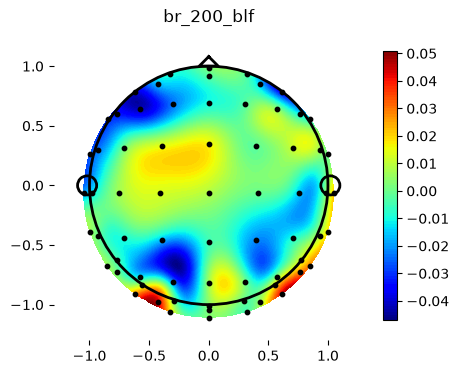

In [21]:
cf.showme2DTopomap(br_data_blf[midpoint,:,],br_meta_data_blf,"br_200_blf")

In [ ]:
midpoint = 1+((br_data.shape[0])//2)
cf.showme3DTopomapnewmesh(br_data[midpoint,:],odd_meta_data,"br_200_blf")

In [ ]:
importlib.reload(FP)
filepath = Path(r"D:\Goffaux lab\Data set\Python files\200 ME MERGED")
npy_data, meta_data, filepath = FP.MEfrequencytransform(filepath,stepno = 91)
npy_data, meta_data, filepath = FP.MEaveragingacrosstrials(filepath,stepno = 101)
npy_data, meta_data, filepath = FP.MEchunking(filepath,stepno = 111)
print(npy_data.shape)

br_data, br_meta_data, br_filepath, odd_data, odd_meta_data, odd_filepath = FP.MEselectingchunks(filepath,stepno = 121, numharmonics=1)
print(br_data.shape)

br_data_sum, br_meta_data, _ = FP.MEsumofharmonics(br_filepath,stepno = 131)
br_data_blf, br_meta_data_blf, filepath_br_blf = FP.MEbaselinefiltering(br_filepath,stepno = 141)

# odd_data, odd_meta_data, filepath_odd = FP.MEsumofharmonics(odd_filepath,stepno = 131)
# odd_data_blf, odd_meta_data_blf, filepath_odd_blf = FP.MEbaselinefiltering(odd_filepath,stepno = 141)
print(odd_data.shape)
# FP.showmesummaryplot(npy_data[:,:,:,0],meta_data)


In [ ]:
# FP.showmesummaryplot(np.squeeze(np.sum(odd_data,axis = 2,keepdims=True)),br_meta_data)
FP.showmesummaryplot(odd_data_blf,br_meta_data)

In [ ]:
freqid = br_data.shape[0]//2-1
data = np.mean(np.sum(odd_data_blf[:,:,:,:],axis = 2),axis = 2)
cf.showme3DTopomapnewmesh(data[freqid,:],br_meta_data,title="200 Baserate Grand average")

In [ ]:
cf.showme2DTopomap(data[freqid,:],br_meta_data,titlestr="200 Baserate Grand average")

In [ ]:
cf.showme3DTopomap(data[freqid,:],br_meta_data,title="200 Baserate Grand average")